**Import Required Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

**Loading the Dataset:**

In [ ]:
df = pd.read_csv("/content/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


**Treating the Missing Values:**

In [ ]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [ ]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

**Pre-Processing:**

In [ ]:
num_features = ['longitude','latitude','housing_median_age','total_rooms',
                'total_bedrooms','population','households','median_income']
cat_features = ['ocean_proximity']

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

**Training Different Models:**

In [ ]:
models = {
    "No Regularization (OLS)": LinearRegression(),
    "Ridge (L2, alpha=10)":    Ridge(alpha=10.0),
    "Lasso (L1, alpha=1000)":  Lasso(alpha=1000.0),
    "ElasticNet (alpha=100, l1_ratio=0.5)": ElasticNet(alpha=100.0, l1_ratio=0.5)
}

In [ ]:
results = {}
coefs = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    non_zero = np.sum(model.coef_ != 0)

    results[name] = {"MSE": mse, "R²": r2, "Non-zero features": non_zero}
    coefs[name] = model.coef_

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    nz  = np.sum(np.abs(model.coef_) > 1e-8)   # practical non-zero count

    results[name] = {"MSE": mse, "R²": r2, "Non-zero": nz}
    coefs[name] = model.coef_

    print(f"{name:<45}  {mse:,.0f}    {r2:.4f}    {nz}/{len(feature_names)}")

No Regularization (OLS)                        4,908,476,721    0.6254    12/12
Ridge (L2, alpha=10)                           4,911,663,625    0.6252    12/12
Lasso (L1, alpha=1000)                         4,945,846,143    0.6226    8/12
ElasticNet (alpha=100, l1_ratio=0.5)           12,809,589,721    0.0225    11/12


**Visualization:**

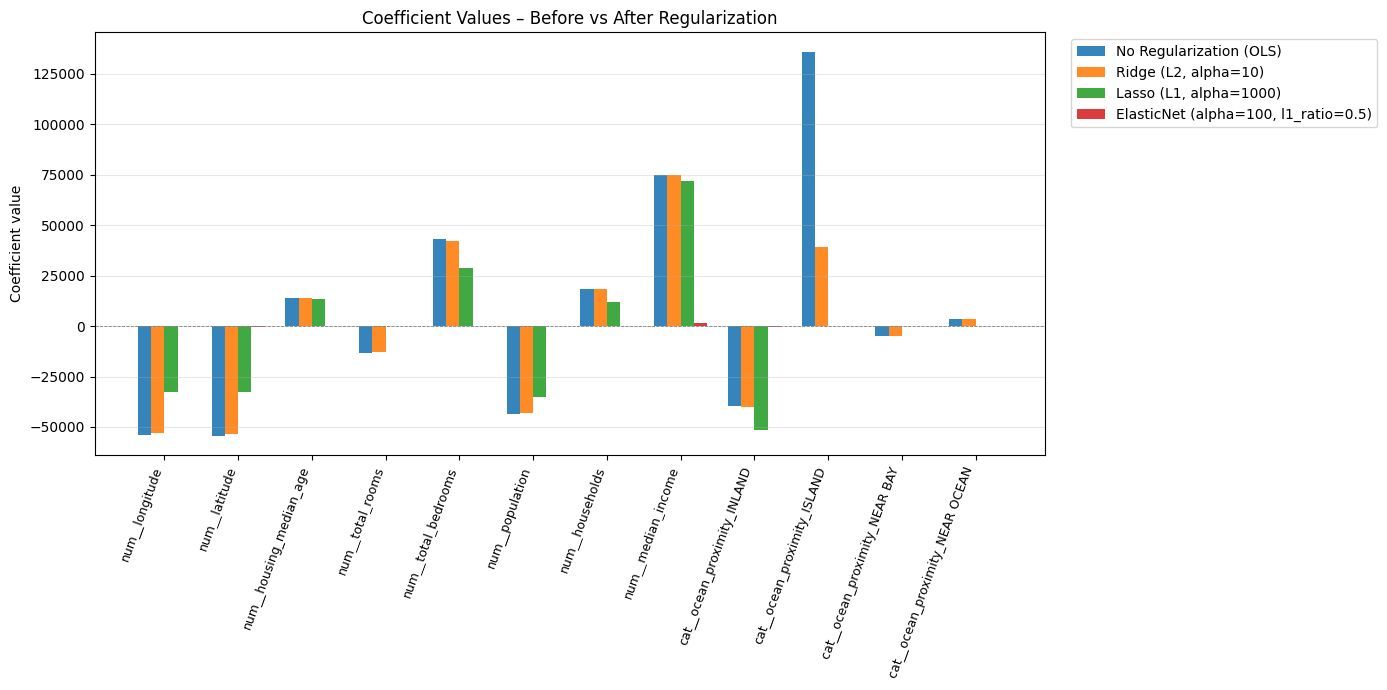

In [ ]:
plt.figure(figsize=(14, 7))
x = np.arange(len(feature_names))
width = 0.18

for i, (name, coef) in enumerate(coefs.items()):
    plt.bar(x + i*width, coef, width, label=name, alpha=0.9)

plt.xticks(x + width*1.5, feature_names, rotation=70, ha='right', fontsize=9)
plt.axhline(0, color='gray', linewidth=0.6, linestyle='--')
plt.ylabel("Coefficient value")
plt.title("Coefficient Values – Before vs After Regularization")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Shrinkage Paths:**

In [ ]:
def plot_shrinkage_path(model_class, alphas, title, **kwargs):
    path_coefs = []
    for a in alphas:
        model = model_class(alpha=a, **kwargs)
        model.fit(X_train, y_train)
        path_coefs.append(model.coef_)

    path_coefs = np.array(path_coefs)

    plt.figure(figsize=(10, 6))
    for i in range(path_coefs.shape[1]):
        plt.plot(np.log10(alphas), path_coefs[:, i], label=feature_names[i], linewidth=1.2)

    plt.xlabel("log₁₀(α) - Increasing Regularization Strength")
    plt.ylabel("Coefficient Value")
    plt.title(f"{title} - Weight Shrinkage & Changes")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
alphas = np.logspace(-2, 4, 40)

**Generating Shrinkage Paths:**

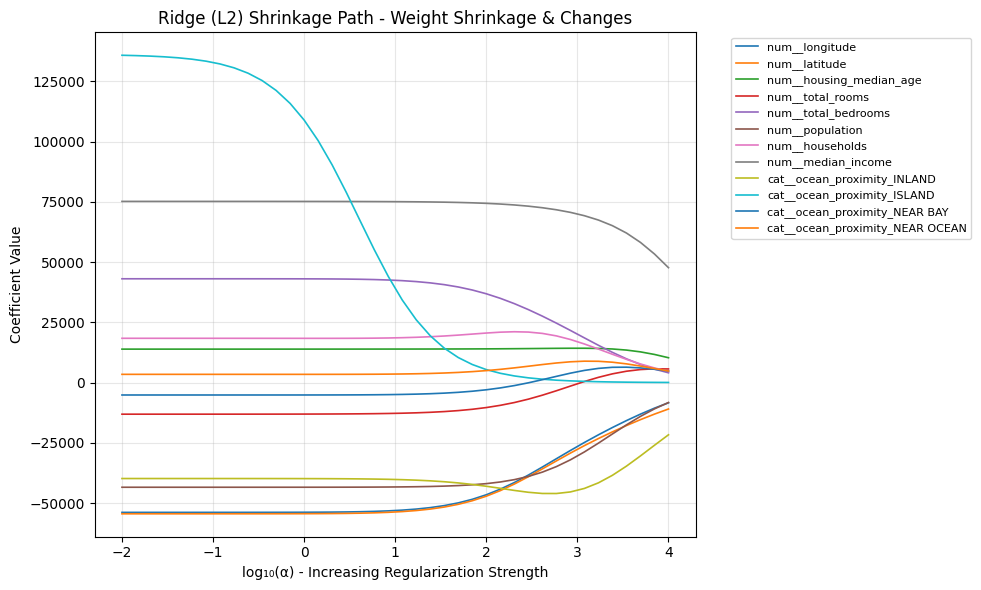

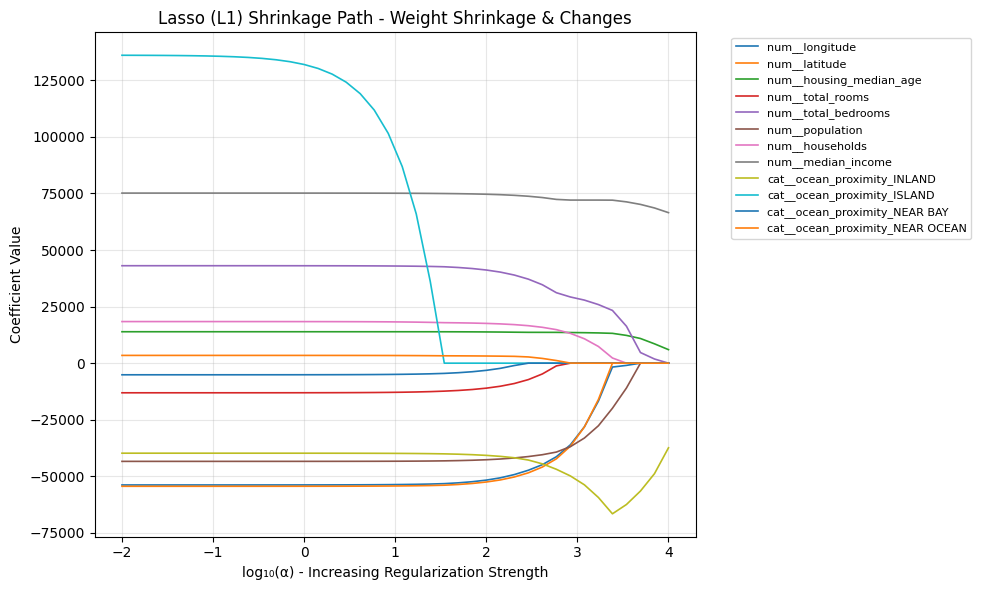

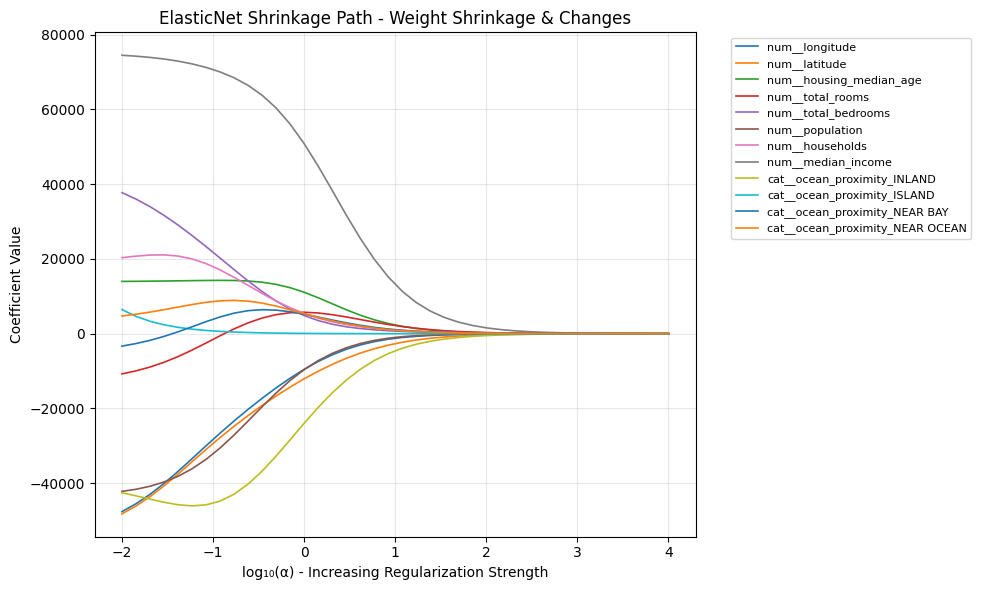

In [ ]:
plot_shrinkage_path(Ridge, alphas, "Ridge (L2) Shrinkage Path")
plot_shrinkage_path(Lasso, alphas, "Lasso (L1) Shrinkage Path", max_iter=2000)
plot_shrinkage_path(ElasticNet, alphas, "ElasticNet Shrinkage Path", l1_ratio=0.5, max_iter=2000)

**INTERPRETATION:**

In this experiment, the impact of L1 (Lasso), L2 (Ridge), and Elastic Net regularization was studied using the California Housing dataset. A baseline Ordinary Linear Regression (OLS) model was first trained without regularization. It produced larger coefficient values, which can increase the risk of overfitting.

After applying Ridge Regression (L2), the coefficients were reduced smoothly. Ridge shrinks all feature weights but does not remove any feature completely, making the model more stable.

With Lasso Regression (L1), many coefficients became exactly zero. This shows that Lasso performs feature selection by eliminating less important features and producing a simpler model.

Elastic Net, which combines both L1 and L2 penalties, showed a balanced behavior by shrinking coefficients like Ridge while also setting some coefficients to zero like Lasso.

The coefficient comparison plots clearly demonstrate that regularization controls model complexity: OLS has the largest weights, Ridge reduces weights, Lasso removes features, and Elastic Net provides a compromise between both. Overall, regularization improves generalization and prevents overfitting by controlling the magnitude of model parameters.